# Section 4, Figure 1

Runs the scaling experiment that compares achieved approximation error with the predicted double-scoring scaling law.

## Run Notes
- Run the notebook from top to bottom.
- Synthetic function-approximation data only.
- The experiment sweeps several target epsilons and extra-width settings.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [1]:
import math

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples."""
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Linear layer with frozen weights and trainable scores that choose the mask."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        double=True,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        multiplier = 2 if double else 1
        self.k = k

        # Scores can be wider than the weight matrix; only the realized weight slice is used.
        self.scores = nn.Parameter(
            torch.randn(out_features, multiplier * in_features + extra_capacity)
        )
        init(self.weight)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(
                torch.randn(multiplier + extra_capacity, out_features)
            )
            self.bias.requires_grad_(False)

    def forward(self, x):
        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[1, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)


class Network(nn.Module):
    """Small MLP assembled from masked LinearSubnet layers."""

    def __init__(
        self,
        layer_sizes,
        init=signed_kaiming_constant_,
        bias=True,
        double=True,
        extra_capacity=0,
    ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        double=double,
                        extra_capacity=extra_capacity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

    def set_ks(self, ks):
        """Update layerwise sparsity values for a grid-search or sweep."""
        k_iter = iter(ks)
        for layer in self.layers:
            if isinstance(layer, LinearSubnet):
                layer.k = next(k_iter)

Using cuda device


## Experiment and Figure

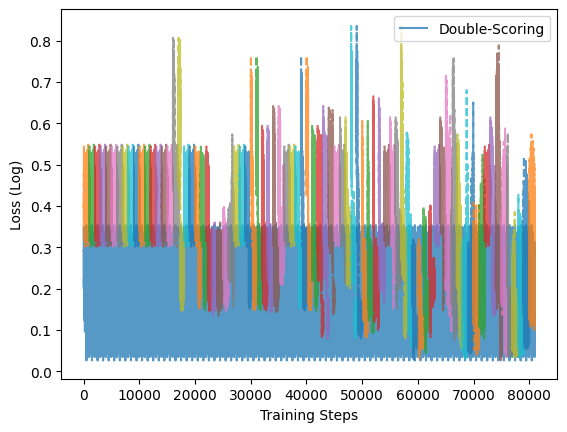

In [3]:
# Experiment outline:
# 1. Train brute-force and double-scoring models on the same sine samples.
# 2. Store the loss trajectory for each sparsity pair.
# 3. Plot brute-force trajectories against the repeated double-scoring trajectory.

data_x = torch.randn(1000,1).to(device)
data_y = torch.sin(data_x)
layer_sizes=[[data_x.shape[1],8],[8,data_y.shape[1]]]
num_epochs = 10
num_steps = 100
model_brute = Network(layer_sizes,bias=False,double=False).to(device)
W0 = model_brute.layers[0].weight.data.clone().to(device)
W1 = model_brute.layers[2].weight.data.clone().to(device)
S0 = model_brute.layers[0].scores.data.clone().to(device)
S1 = model_brute.layers[2].scores.data.clone().to(device)
first_layer_size = model_brute.layers[0].weight.numel()
second_layer_size = model_brute.layers[2].weight.numel()
losses={}
shuffled_indices_seq = [[torch.randperm(len(data_x))[:64]for i in range(num_steps)] for e in range(num_epochs)]
for k1 in range(first_layer_size+1):
  for k2 in range(second_layer_size+1):
    model_brute.layers[0].weight.data = W0.clone()
    model_brute.layers[2].weight.data = W1.clone()
    model_brute.layers[0].scores.data = S0.clone()
    model_brute.layers[2].scores.data = S1.clone()
    model_brute.set_ks([k1/(first_layer_size),k2/(second_layer_size)])
    losses[(k1,k2)]=[]
    optimizer_brute=torch.optim.Adam(model_brute.parameters())
    for e in range(num_epochs):
      for i in range(num_steps):
        shuffled_indices = shuffled_indices_seq[e][i]
        optimizer_brute.zero_grad()
        loss=nn.MSELoss()(model_brute(data_x[shuffled_indices]),data_y[shuffled_indices])
        loss.backward()
        optimizer_brute.step()
        losses[(k1,k2)].append(loss.item())
model_double_scoring=Network(layer_sizes,bias=False).to(device)
model_double_scoring.layers[0].weight.data = W0.clone()
model_double_scoring.layers[2].weight.data = W1.clone()
optimizer_double_scoring = torch.optim.Adam(model_double_scoring.parameters())
losses_double_scoring=[]
for e in range(num_epochs):
  for i in range(num_steps):
        shuffled_indices = shuffled_indices_seq[e][i]
        optimizer_double_scoring.zero_grad()
        loss=nn.MSELoss()(model_double_scoring(data_x[shuffled_indices]),data_y[shuffled_indices])
        loss.backward()
        optimizer_double_scoring.step()
        losses_double_scoring.append(loss.item())
count=0
repeated_losses_double_scoring = []
for k1 in range(model_brute.layers[0].weight.shape[0]*model_brute.layers[0].weight.shape[1]+1):
  for k2 in range(model_brute.layers[2].weight.shape[0]*model_brute.layers[2].weight.shape[1]+1):
    count+=len(losses[(k1,k2)])
    repeated_losses_double_scoring = repeated_losses_double_scoring+losses_double_scoring
plt.plot([i for i in range(count)],repeated_losses_double_scoring, alpha=0.75, label='Double-Scoring')
count=0
for k1 in range(model_brute.layers[0].weight.shape[0]*model_brute.layers[0].weight.shape[1]+1):
  for k2 in range(model_brute.layers[2].weight.shape[0]*model_brute.layers[2].weight.shape[1]+1):
    plt.plot([i+count for i in range(len(losses[(k1,k2)]))],losses[(k1,k2)],alpha=0.75,ls='--')
    count+=len(losses[(k1,k2)])
plt.xlabel("Training Steps")
plt.ylabel("Loss (Log)")
plt.legend()